# Overhead Press Form-Error Detection — EDA

Dataset characterization for the OHP Elbows/Knees form-error task on the **Fitness-AQA**
official splits (Parmar et al., ECCV 2022). Class balance, the Elbows↔Knees co-occurrence,
and clip counts — the evidence behind the modeling choices (joint shared-backbone head,
class-weighted loss).

Reads the local Fitness-AQA OHP archive (research-use only; not committed). The executed
`.ipynb` embeds the outputs so it is viewable without the archive.

## Setup — locate the OHP labeled archive

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_CANDS = [
    Path("Fitness-AQA/Fitness-AQA_dataset_release-20260518T073812Z-3-001/"
         "Fitness-AQA_dataset_release/OHP/Labeled_Dataset"),
    Path("../../Fitness-AQA/Fitness-AQA_dataset_release-20260518T073812Z-3-001/"
         "Fitness-AQA_dataset_release/OHP/Labeled_Dataset"),
]
LAB = next((p for p in _CANDS if p.exists()), None)
assert LAB is not None, "local OHP archive not found"
print("archive:", LAB)

elbows = json.load(open(LAB / "Labels/error_elbows.json"))
knees = json.load(open(LAB / "Labels/error_knees.json"))
splits = {s: json.load(open(LAB / f"Splits/{s}_keys.json")) for s in ("train", "val", "test")}
print("counts:", {s: len(k) for s, k in splits.items()})

archive: ..\..\Fitness-AQA\Fitness-AQA_dataset_release-20260518T073812Z-3-001\Fitness-AQA_dataset_release\OHP\Labeled_Dataset
counts: {'train': 1582, 'val': 339, 'test': 339}


## 1. Official split sizes

2,260 labeled clips, used verbatim — no reshuffle, identical to the paper.

In [2]:
for s in ("train", "val", "test"):
    print(f"{s:>5}: {len(splits[s])} clips")
print("total:", sum(len(k) for k in splits.values()))

train: 1582 clips
  val: 339 clips
 test: 339 clips
total: 2260


## 2. Class balance per split

Both errors are moderate-minority (Elbows ~26%, Knees ~34%) — better balanced than
Squat's rare-KIE (14%) / majority-KFE (68%). This drives the per-error `pos_weight`.

train: Elbows+ 25.7%   Knees+ 34.2%
  val: Elbows+ 24.5%   Knees+ 31.9%
 test: Elbows+ 25.4%   Knees+ 37.8%


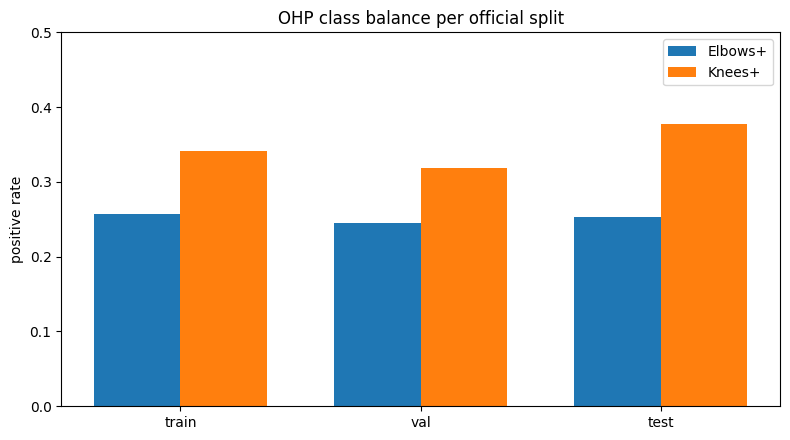

In [3]:
def pos(m, k):
    return bool(m.get(k))

rates = {s: {"Elbows": np.mean([pos(elbows, k) for k in ks]),
             "Knees": np.mean([pos(knees, k) for k in ks])} for s, ks in splits.items()}
for s in ("train", "val", "test"):
    print(f"{s:>5}: Elbows+ {rates[s]['Elbows']*100:4.1f}%   Knees+ {rates[s]['Knees']*100:4.1f}%")

sp = ["train", "val", "test"]; x = np.arange(3); w = 0.36
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, [rates[s]["Elbows"] for s in sp], w, color="C0", label="Elbows+")
ax.bar(x + w/2, [rates[s]["Knees"] for s in sp], w, color="C1", label="Knees+")
ax.set_xticks(x); ax.set_xticklabels(sp); ax.set_ylabel("positive rate"); ax.set_ylim(0, 0.5)
ax.set_title("OHP class balance per official split"); ax.legend(); fig.tight_layout(); plt.show()

## 3. Elbows ↔ Knees co-occurrence

The two errors are **largely independent**: of the train Elbows+ clips, only a small
fraction are also Knees+ (Elbows is upper-body, Knees lower-body). So the joint two-output
head is justified by the **shared MD-SSL motion representation + efficiency**, NOT by error
co-occurrence. `BCEWithLogitsLoss` treats the two heads independently, which is correct here.

train (n=1582): both 85 | Elbows-only 322 | Knees-only 456 | neither 719
of 407 Elbows+ clips, only 85 (21%) are also Knees+


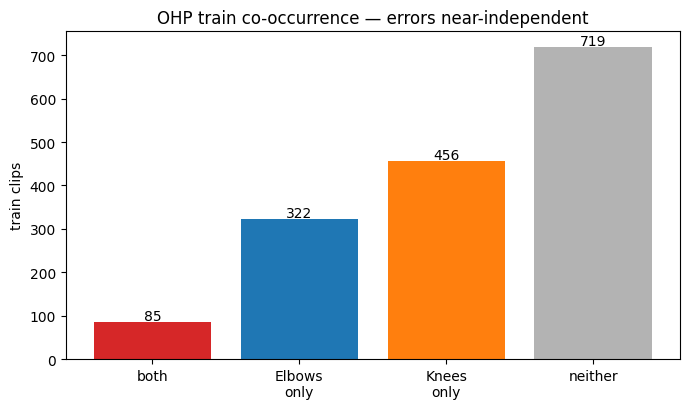

In [4]:
tr = splits["train"]
both = sum(pos(elbows, k) and pos(knees, k) for k in tr)
e_only = sum(pos(elbows, k) and not pos(knees, k) for k in tr)
k_only = sum(not pos(elbows, k) and pos(knees, k) for k in tr)
neither = len(tr) - both - e_only - k_only
print(f"train (n={len(tr)}): both {both} | Elbows-only {e_only} | Knees-only {k_only} | neither {neither}")
print(f"of {e_only+both} Elbows+ clips, only {both} ({100*both/(e_only+both):.0f}%) are also Knees+")

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(["both", "Elbows\nonly", "Knees\nonly", "neither"], [both, e_only, k_only, neither],
              color=["C3", "C0", "C1", "0.7"])
for b, v in zip(bars, [both, e_only, k_only, neither]):
    ax.text(b.get_x()+b.get_width()/2, v+5, str(v), ha="center")
ax.set_ylabel("train clips"); ax.set_title("OHP train co-occurrence — errors near-independent")
fig.tight_layout(); plt.show()

## Notes
- Splits used verbatim; `pos_weight` derived from train counts (Elbows ≈ 2.89, Knees ≈ 1.92).
- Video clips are single reps (~3 s @ 30 fps); labels are `[start, end]` intervals
  (non-empty ⇒ error present). Barbell trajectories ship for the unlabeled set (used for
  the MD-SSL half-cycle split — see notebook 07).